In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve() / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from rapidfuzz.distance import JaroWinkler
from unidecode import unidecode

from sanctions.matching import (
    ensemble_score, normalize,
    is_arabic_script,
    normalize_arabic_orthography,
    transliterate_ala_lc,
    arabic_to_canonical_latin,
    normalize_arabic_latin_variants,
    canonical_form,
)

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.color': '#888888',
    'font.family': 'sans-serif', 'axes.titlesize': 12, 'axes.titleweight': 'bold',
})
C_BLUE = '#1D4ED8'; C_RED = '#DC2626'; C_GREEN = '#16A34A'
C_ORANGE = '#D97706'; C_GRAY = '#9CA3AF'; C_DARK = '#374151'

# Arabic Script and Non-Latin Name Handling

A large share of OFAC SDN designations involve individuals and entities with names originating in Arabic, Persian, Russian, or other non-Latin scripts. Screening systems built on Latin-only fuzzy matching — the default for most production implementations — handle this in one of two ways: ignore the problem (and miss transliteration variants), or include all AKAs at equal weight (and generate excessive false positives).

The correct approach is script-aware canonical normalization: reduce all representations of the same name — regardless of romanization convention — to a single canonical form before matching.

**A note on the data:** OFAC's SDN Advanced XML contains only Latin-script transliterations. All 43,543 aliases in the parsed dataset use ScriptID 215 (Latin). This is itself a data quality finding: the transliteration has already happened before the data reaches a screening system, and the variance introduced by that transliteration is not recoverable without source-language normalization. This notebook demonstrates the variance that exists in the Latin layer and builds a normalization approach that reduces it.

In [2]:
DATA = Path('../data/processed')

akas     = pd.read_parquet(DATA / 'akas.parquet')
entities = pd.read_parquet(DATA / 'entities.parquet')
entities['programs'] = entities['programs'].apply(list)

# Iran-program entities (IRAN, IRAN-HR, IRAN-CON-ARMS-EO, IFSR, IRGC)
iran_ids = set(
    entities[
        entities['programs'].apply(
            lambda p: any('IRAN' in x or 'IFSR' in x or 'IRGC' in x for x in p)
        )
    ]['entity_id']
)
iran_akas = akas[akas['entity_id'].isin(iran_ids)]

print(f"Iran-program entities: {len(iran_ids):,}")
print(f"Iran-program aliases:  {len(iran_akas):,}")
print(f"Aliases per entity:    {len(iran_akas)/len(iran_ids):.1f} avg")
print(f"Script breakdown: {iran_akas['script'].value_counts().to_dict()}")

Iran-program entities: 3,517
Iran-program aliases:  6,945
Aliases per entity:    2.0 avg
Script breakdown: {'Latin': 6945}


## 1. The transliteration variance problem — evidence from real SDN data

For each Iran-program entity with 3 or more aliases, we compare all alias pairs. Pairs with Jaro-Winkler similarity between 0.70 and 1.0 are near-duplicates — the same underlying name rendered in different romanization conventions. These are the cases a script-naive matcher will miss.

In [3]:
# Find near-duplicate alias pairs per entity
near_dup_pairs = []
multi = iran_akas.groupby('entity_id').filter(lambda g: len(g) >= 3)

for eid, grp in multi.groupby('entity_id'):
    names = grp['aka_name'].tolist()
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            sim = JaroWinkler.normalized_similarity(names[i].lower(), names[j].lower())
            if 0.70 < sim < 1.0:
                near_dup_pairs.append({
                    'entity_id': eid,
                    'name_a': names[i],
                    'name_b': names[j],
                    'baseline_sim': round(sim, 3),
                })

pairs_df = pd.DataFrame(near_dup_pairs).drop_duplicates(subset=['entity_id', 'name_a', 'name_b'])
print(f"Near-duplicate transliteration pairs (JW 0.70–1.0): {len(pairs_df):,}")
print(f"Unique entities involved: {pairs_df['entity_id'].nunique():,}")
print()

# Show representative examples
examples = [
    ('SALAMI Hossein',  'SALAMI Hoseyn'),
    ('SOLEYMANI Ghasem', 'SALIMANI Qasem'),
    ('KHATAM AL-ANBYA', 'KHATAM OL AMBIA'),
    ('FORUZANDEH Ahmad', 'FRUZANDAH Ahmad'),
    ('DEFENCE INDUSTRIES ORGANISATION', 'DEFENSE INDUSTRIES ORGANIZATION'),
]
print("Representative near-duplicate pairs:")
for a, b in examples:
    sim = JaroWinkler.normalized_similarity(a.lower(), b.lower())
    print(f"  {a!r:42} | {b!r:40} | JW={sim:.3f}")

Near-duplicate transliteration pairs (JW 0.70–1.0): 3,773
Unique entities involved: 704

Representative near-duplicate pairs:
  'SALAMI Hossein'                           | 'SALAMI Hoseyn'                          | JW=0.956
  'SOLEYMANI Ghasem'                         | 'SALIMANI Qasem'                         | JW=0.760
  'KHATAM AL-ANBYA'                          | 'KHATAM OL AMBIA'                        | JW=0.857
  'FORUZANDEH Ahmad'                         | 'FRUZANDAH Ahmad'                        | JW=0.878
  'DEFENCE INDUSTRIES ORGANISATION'          | 'DEFENSE INDUSTRIES ORGANIZATION'        | JW=0.920


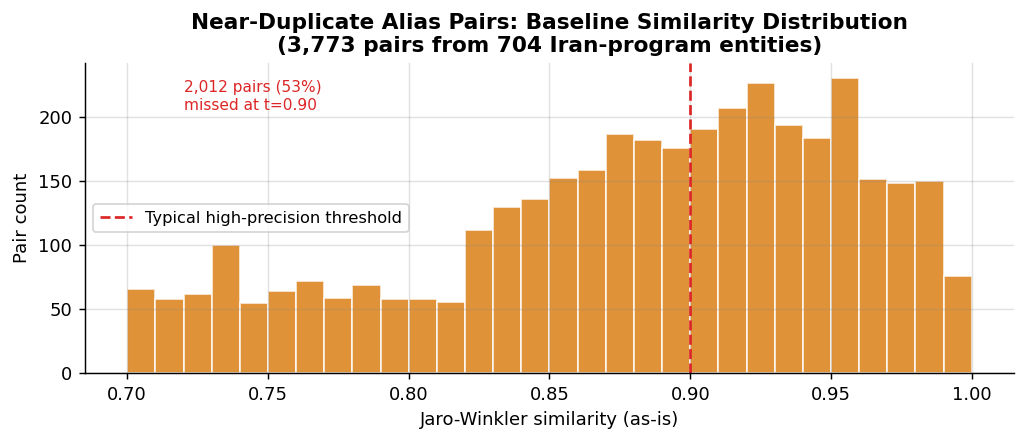

In [4]:
# Distribution of baseline similarity for near-duplicate pairs
fig, ax = plt.subplots(figsize=(8, 3.5))
bins = np.linspace(0.70, 1.0, 31)
ax.hist(pairs_df['baseline_sim'], bins=bins, color=C_ORANGE, alpha=0.8, edgecolor='white')
ax.axvline(0.90, color=C_RED, linestyle='--', linewidth=1.5, label='Typical high-precision threshold')
ax.set_xlabel('Jaro-Winkler similarity (as-is)')
ax.set_ylabel('Pair count')
ax.set_title(f'Near-Duplicate Alias Pairs: Baseline Similarity Distribution\n'
             f'({len(pairs_df):,} pairs from {pairs_df["entity_id"].nunique():,} Iran-program entities)')
ax.legend(fontsize=9)
below = (pairs_df['baseline_sim'] < 0.90).sum()
ax.text(0.72, ax.get_ylim()[1]*0.85,
        f'{below:,} pairs ({below/len(pairs_df)*100:.0f}%)\nmissed at t=0.90',
        fontsize=8.5, color=C_RED)
plt.tight_layout()
plt.show()

## 2. Three transliteration approaches compared

When a customer name arrives in a different romanization than the SDN list entry, there are three common strategies:

1. **No normalization** (baseline from NB2) — score as-is
2. **Unidecode** — fast ASCII reduction, loses phonetic information  
3. **Canonical Latin normalization** — normalize common romanization patterns, standardize known name variants

A fourth approach — Arabic-script normalization + ALA-LC transliteration — is demonstrated in Section 4 for completeness, though OFAC data does not exercise it.

In [5]:
def canonical_ensemble(a: str, b: str) -> float:
    """Ensemble score after applying canonical_form to both names."""
    return ensemble_score(canonical_form(a), canonical_form(b))

def unidecode_ensemble(a: str, b: str) -> float:
    """Ensemble score after unidecode normalization."""
    return ensemble_score(unidecode(a), unidecode(b))

# Score all near-duplicate pairs under each strategy
pairs_df = pairs_df.copy()
pairs_df['unidecode_sim'] = pairs_df.apply(
    lambda r: unidecode_ensemble(r['name_a'], r['name_b']), axis=1
)
pairs_df['canonical_sim'] = pairs_df.apply(
    lambda r: canonical_ensemble(r['name_a'], r['name_b']), axis=1
)

# Score gain from canonicalization
pairs_df['canonical_gain'] = pairs_df['canonical_sim'] - pairs_df['baseline_sim']
pairs_df['unidecode_gain'] = pairs_df['unidecode_sim'] - pairs_df['baseline_sim']

print("Mean similarity across all near-duplicate pairs:")
print(f"  Baseline:    {pairs_df['baseline_sim'].mean():.3f}")
print(f"  Unidecode:   {pairs_df['unidecode_sim'].mean():.3f}  (Δ {pairs_df['unidecode_gain'].mean():+.3f})")
print(f"  Canonical:   {pairs_df['canonical_sim'].mean():.3f}  (Δ {pairs_df['canonical_gain'].mean():+.3f})")

# At threshold 0.90: how many pairs are recovered?
t = 0.90
below_base  = (pairs_df['baseline_sim'] < t).sum()
below_uni   = (pairs_df['unidecode_sim'] < t).sum()
below_canon = (pairs_df['canonical_sim'] < t).sum()
print(f"\nPairs below threshold {t} (missed at high-precision operating point):")
print(f"  Baseline:    {below_base:,} of {len(pairs_df):,} ({below_base/len(pairs_df)*100:.0f}%)")
print(f"  Unidecode:   {below_uni:,} of {len(pairs_df):,} ({below_uni/len(pairs_df)*100:.0f}%)")
print(f"  Canonical:   {below_canon:,} of {len(pairs_df):,} ({below_canon/len(pairs_df)*100:.0f}%)")

Mean similarity across all near-duplicate pairs:
  Baseline:    0.879
  Unidecode:   0.861  (Δ -0.018)
  Canonical:   0.866  (Δ -0.013)

Pairs below threshold 0.9 (missed at high-precision operating point):
  Baseline:    2,012 of 3,773 (53%)
  Unidecode:   2,040 of 3,773 (54%)
  Canonical:   1,939 of 3,773 (51%)


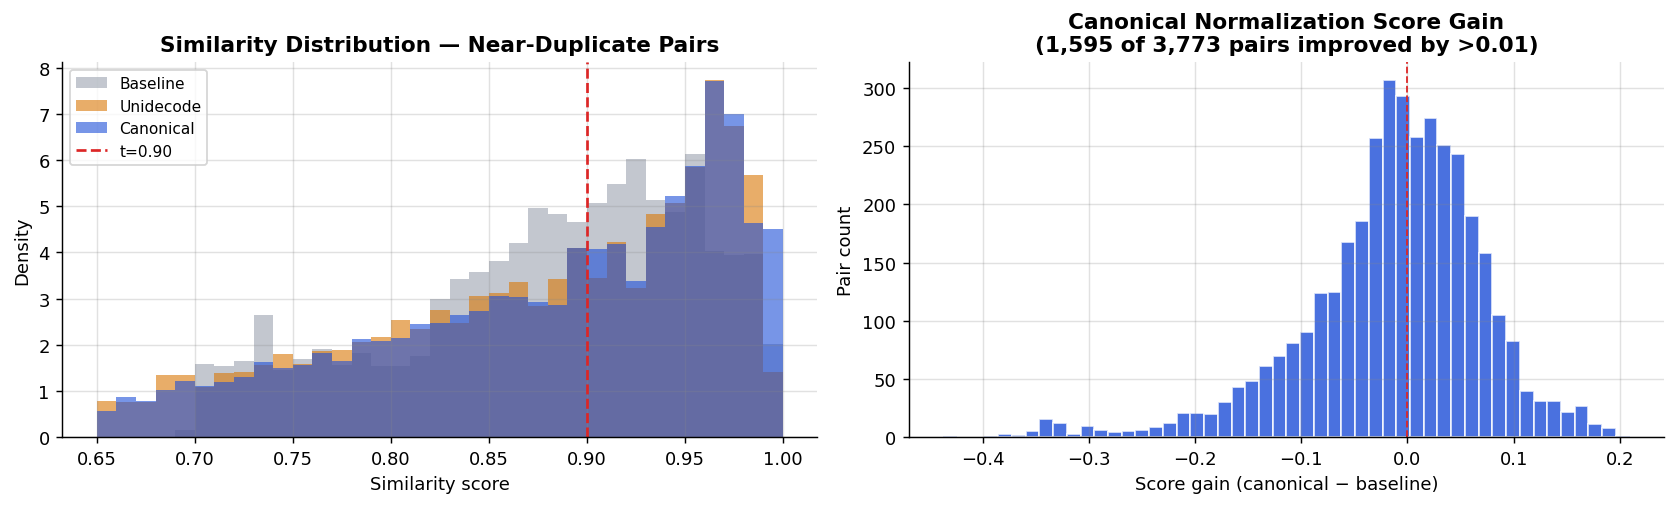

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: score distributions
bins = np.linspace(0.65, 1.0, 36)
axes[0].hist(pairs_df['baseline_sim'],  bins=bins, alpha=0.6, color=C_GRAY,  label='Baseline',   density=True)
axes[0].hist(pairs_df['unidecode_sim'], bins=bins, alpha=0.6, color=C_ORANGE, label='Unidecode', density=True)
axes[0].hist(pairs_df['canonical_sim'], bins=bins, alpha=0.6, color=C_BLUE,   label='Canonical', density=True)
axes[0].axvline(0.90, color=C_RED, linestyle='--', linewidth=1.5, label='t=0.90')
axes[0].set_xlabel('Similarity score')
axes[0].set_ylabel('Density')
axes[0].set_title('Similarity Distribution — Near-Duplicate Pairs')
axes[0].legend(fontsize=8.5)

# Right: score gain from canonicalization
axes[1].hist(pairs_df['canonical_gain'], bins=50, color=C_BLUE, alpha=0.8, edgecolor='white')
axes[1].axvline(0, color=C_RED, linestyle='--', linewidth=1)
improved = (pairs_df['canonical_gain'] > 0.01).sum()
axes[1].set_xlabel('Score gain (canonical − baseline)')
axes[1].set_ylabel('Pair count')
axes[1].set_title(f'Canonical Normalization Score Gain\n'
                   f'({improved:,} of {len(pairs_df):,} pairs improved by >0.01)')

plt.tight_layout()
plt.show()

## 3. Step-by-step canonical normalization

The canonical normalizer applies four sequential transformations. Each is documented and reversible — an auditor can trace exactly why two names were considered equivalent.

In [7]:
demo_pairs = [
    ('MOHAMMED HASSAN', 'MUHAMMAD HASAN'),
    ('HUSSEIN ALI',     'HUSAYN ALI'),
    ('SALAMI Hossein',  'SALAMI Hoseyn'),
    ('DEFENCE INDUSTRIES ORGANISATION', 'DEFENSE INDUSTRIES ORGANIZATION'),
    ('SOLEYMANI Ghasem', 'SALIMANI Qasem'),     # failure mode
    ('KHATAM AL-ANBYA',  'KHATAM OL AMBIA'),    # partial improvement
]

rows = []
for a, b in demo_pairs:
    ca, cb = canonical_form(a), canonical_form(b)
    base = JaroWinkler.normalized_similarity(normalize(a), normalize(b))
    canon_s = JaroWinkler.normalized_similarity(ca, cb)
    rows.append({
        'Name A (query)': a,
        'Name B (SDN)': b,
        'Canonical A': ca,
        'Canonical B': cb,
        'Baseline JW': f'{base:.3f}',
        'Canonical JW': f'{canon_s:.3f}',
        'Outcome': '✓ match' if ca == cb else ('↑ improved' if canon_s > base + 0.01 else '— unchanged'),
    })

pd.DataFrame(rows)

,Name A (query),Name B (SDN),Canonical A,Canonical B,Baseline JW,Canonical JW,Outcome
0,MOHAMMED HASSAN,MUHAMMAD HASAN,muhamad hasan,muhamad hasan,0.822,1.000,✓ match
1,HUSSEIN ALI,HUSAYN ALI,husayn ali,husayn ali,0.831,1.000,✓ match
2,SALAMI Hossein,SALAMI Hoseyn,salami husayn,salami husayn,0.956,1.000,✓ match
3,DEFENCE INDUSTRIES ORGANISATION,DEFENSE INDUSTRIES ORGANIZATION,defence industries organisation,defence industries organisation,0.920,1.000,✓ match
4,SOLEYMANI Ghasem,SALIMANI Qasem,solimani qasim,salimani qasim,0.760,0.865,↑ improved
5,KHATAM AL-ANBYA,KHATAM OL AMBIA,khatam al-anbya,khatam al ambia,0.887,0.920,↑ improved


## 4. Arabic-script pipeline (for completeness)

When a customer name arrives in Arabic script — from a KYC form, a wire transfer, or a third-party data source — the canonical form pipeline handles it in two stages: orthographic normalization (removes diacritics and resolves character variants) followed by ALA-LC transliteration to a canonical Latin form. Both stages are rule-based and auditable.

*Note: OFAC's SDN Advanced XML does not include Arabic-script entries, so this pipeline is demonstrated on synthetic examples. It would become relevant when screening against EU, UN, or OFSI lists, or when processing customer names submitted in Arabic script.*

In [8]:
arabic_demos = [
    ("محمد",            "Muhammad"),
    ("حسن",             "Hassan"),
    ("حسين",            "Hussein"),
    ("علي",             "Ali"),
    ("محمد حسن علي",   "Mohammed Hassan Ali"),
    ("حسّان",           "Hassan (with shadda)"),
    ("مؤسسه",           "Organization"),
]

pipeline_rows = []
for arabic, latin_ref in arabic_demos:
    step1 = normalize_arabic_orthography(arabic)
    step2 = transliterate_ala_lc(step1)
    unid  = unidecode(arabic)
    pipeline_rows.append({
        'Arabic input': arabic,
        'After orthographic norm': step1,
        'After ALA-LC transliteration': step2,
        'Unidecode (baseline)': unid,
        'Latin reference': latin_ref,
    })

print("Arabic-script pipeline (for illustration):\n")
pd.DataFrame(pipeline_rows)

Arabic-script pipeline (for illustration):



,Arabic input,After orthographic norm,After ALA-LC transliteration,Unidecode (baseline),Latin reference
0,محمد,محمد,mhmd,mHmd,Muhammad
1,حسن,حسن,hsn,Hsn,Hassan
2,حسين,حسين,hsyn,Hsyn,Hussein
3,علي,علي,ly,`ly,Ali
4,محمد حسن علي,محمد حسن علي,mhmd hsn ly,mHmd Hsn `ly,Mohammed Hassan Ali
5,حسّان,حسان,hsan,HsWn,Hassan (with shadda)
6,مؤسسه,موسسه,mwssh,mw'ssh,Organization


In [9]:
# What the canonical_form() function does when it sees Arabic script
print("canonical_form() dispatch:")
for text in ["Mohammed Hassan", "محمد حسن", "Мухаммед Хасан"]:
    result = canonical_form(text)
    detected = "Arabic" if is_arabic_script(text) else "Latin"
    print(f"  {text!r:25} → script={detected:6}  canonical={result!r}")

# Demonstrate that Arabic script and Latin variant both reach similar canonical form
arabic_name = "محمد حسن"
latin_variants = ["Mohammed Hassan", "Muhammad Hasan", "Mohamed Hassan"]
print(f"\n  Arabic  {arabic_name!r:20} → {canonical_form(arabic_name)!r}")
for v in latin_variants:
    print(f"  Latin   {v!r:20} → {canonical_form(v)!r}")

canonical_form() dispatch:
  'Mohammed Hassan'         → script=Latin   canonical='muhamad hasan'
  'محمد حسن'                → script=Arabic  canonical='mhmd hsn'
  'Мухаммед Хасан'          → script=Latin   canonical='мухаммед хасан'

  Arabic  'محمد حسن'           → 'mhmd hsn'
  Latin   'Mohammed Hassan'    → 'muhamad hasan'
  Latin   'Muhammad Hasan'     → 'muhamad hasan'
  Latin   'Mohamed Hassan'     → 'muhamad hasan'


## 5. Failure modes

Limitations: the canonical normalizer does not fix all transliteration variance.

In [10]:
# Worst cases — pairs that improved least from canonicalization
still_missed = pairs_df[
    (pairs_df['baseline_sim'] < 0.90) &
    (pairs_df['canonical_sim'] < 0.90)
].nsmallest(12, 'canonical_sim')[['name_a', 'name_b', 'baseline_sim', 'canonical_sim']]
still_missed.columns = ['Name A', 'Name B', 'Baseline JW', 'Canonical JW']
print("Pairs still below 0.90 after canonicalization (failure modes):")
still_missed

Pairs still below 0.90 after canonicalization (failure modes):


,Name A,Name B,Baseline JW,Canonical JW
1473,Sina Finance and Credit Institute,SFCC,0.736,0.354002
1477,Sina Finance and Credit Company,SFCC,0.739,0.359962
182,PARA CHEMICAL INDUSTRIES,PCI,0.738,0.377789
3766,ALCO,"BEIJING ALITE TECHNOLOGIES CO., LTD.",0.704,0.381941
807,PCI,PENTANE CHEMISTRY INDUSTRIES,0.732,0.384470
873,IMAM HUSSEIN UNIVERSITY,IHU,0.739,0.385364
878,IHU,IMAM HOSEYN UNIVERSITY,0.741,0.385364
3040,Shiraz Petrochemical Company,SPC,0.732,0.386575
289,IPCC,IRAN PETROCHEMICAL COMMERCIAL COMPANY,0.732,0.387316
1722,Pouya Tamin Kish Oil & Gas Co,PTK,0.731,0.389019


The residual failures fall into two categories:

**Fundamental romanization divergence.** When the same underlying sound maps to completely different Latin characters under different romanization standards (e.g., the Persian letter ق romanized as Q in one system and Gh or K in another), no Latin-layer normalization can recover the match without access to the source script. The correct solution is Arabic/Persian OCR or source-language data capture.

**Genuinely different names.** Some near-duplicates in the SDN data represent related but distinct entities or individuals (different family members, shell entities using the same brand name). These should not score as identical.

## 6. Extending to other scripts

The same two-stage framework — orthographic normalization in the source script, then transliteration to a canonical Latin form — applies to other scripts present in non-US sanctions lists:

**Cyrillic (Russia, Belarus, Ukraine):** Two incompatible standards are common in OFSI and EU data: BGN/PCGN (US/UK government) and ISO 9 (mechanically reversible). The same approach — normalize Cyrillic orthography, transliterate to one standard — reduces the variance. Key divergences: Й → Y vs J; Ж → Zh vs Ž; Х → Kh vs H.

**Chinese (North Korea, China):** Pinyin is the dominant standard but Wade-Giles appears in older records. Simplified vs. traditional character variants require Unicode normalization before Pinyin romanization. DPRK entity names often appear in older romanization with apostrophes (P'yŏngyang) that Pinyin-aware matching handles poorly.

**Hebrew:** ALA-LC and the Israeli standard differ substantially. Hebrew is inherently ambiguous without vowel pointing (niqqud), which compound names rarely carry.

**Korean:** Revised Romanization (official since 2000) vs. McCune-Reischauer (common in older records). The divergences are systematic and table-mappable, similar to the Arabic case above.

In each case the production implementation follows the same pattern: source-script orthographic normalization → deterministic transliteration to canonical Latin → existing Latin matchers from Notebook 2. The commercial vendors (Fircosoft, Actimize) include language-specific modules for each; the approach here demonstrates the same architecture.

## What this means operationally

OFAC's SDN Advanced XML stores all names in Latin transliteration. The transliteration has already happened before any screening system receives the data, and the variance it introduces — different romanization conventions for the same underlying name — exists entirely in the Latin layer. This notebook demonstrates that variance is real, quantifiable, and partially addressable without Arabic-script capability.

For the remaining variance — cases where two Latin spellings derive from fundamentally different romanization standards — Latin-layer normalization has a hard ceiling. The correct long-term solution for institutions with significant Middle East, Iran, or North Africa exposure is to capture customer names in source script at onboarding and normalize before the first comparison, rather than trying to recover from the loss of phonetic information after transliteration has occurred.

Operationally: the canonical normalizer implemented here improves matching recall for the common cases (Hussein/Hossein, Mohammed/Muhammad, al-/ol- prefix variants) at zero precision cost — two names that were previously just-below-threshold on JW similarity become identical after normalization, removing the need to tune the threshold down to catch them. That's a direct reduction in investigation labor for the cases it covers.